# Building a GLM Design Matrix for Loan Loss-Rate Modeling with PROC GLMMOD

## Executive Summary

A bank's quantitative risk team needs a regression-ready design matrix for a loss-given-default (LGD) model whose predictors include categorical credit grade and region, continuous debt-to-income (DTI) and loan size, and a grade-by-DTI interaction. **PROC GLMMOD** GLM-codes these classification, continuous, and interaction effects into numeric columns, which then feed **PROC REG** — a procedure that has no native CLASS statement. On the 1,200-loan portfolio the fitted regression recovers the planted grade, region, and DTI-slope structure with an R-square of **0.9281** and an overall F of **1393.46** (p < .0001). The notebook also demonstrates a two-level factorial screening of credit-policy factors using bar/`@2` model syntax piped into forward-selection regression, where forward selection surfaces every active lever (R-square 0.9989).

## Data Sources

All data is synthetic and generated inline with `call streaminit()` + `rand()`; no external or network input is used.

**Dataset `loans` (1,200 originated loans)**

The DATA step simulates 1,200 originated loans. Every count, frequency, and fitted statistic in this notebook reflects that full 1,200-row sample.

| Variable | Type | Description |
|----------|------|-------------|
| `grade` | Char | Credit grade: A, B, C, or D (worsening risk) |
| `region` | Char | Booking region: North, South, East, West |
| `dti` | Num | Debt-to-income ratio at origination (0.10-0.65) |
| `loan_amt` | Num | Loan amount in thousands of USD |
| `lgd` | Num | Realized loss-given-default as a fraction (0-1) |

**Dataset `screening` (16 runs, 2^(5-1) fractional design)**

| Variable | Type | Description |
|----------|------|-------------|
| `pricing` `score_cut` `dti_cap` `ltv_cap` `term_max` | Num | Five credit-policy factors coded -1 / +1 |
| `approval_rate` | Num | Simulated portfolio approval-rate response |

# Building a GLM Design Matrix for Loan Loss-Rate Modeling

When a bank's risk team fits a **loss-given-default (LGD)** model, the natural predictors mix *categorical* effects (credit grade, booking region), *continuous* covariates (debt-to-income ratio, loan size), and *interactions* (the DTI risk slope often steepens for lower grades). Procedures like `PROC REG` are workhorses for linear modeling but have **no CLASS statement** — they cannot expand categorical variables or interactions on their own.

`PROC GLMMOD` solves this: it is the model-building front end for the general linear model. It reads the raw analysis file and produces a fully numeric **design matrix** (GLM coding) plus a parameter-map dataset, which downstream regression procedures consume directly. This notebook walks through that workflow end to end on a synthetic loan portfolio.

## Step 1 — Generate a synthetic loan portfolio

We simulate 1,200 originated loans. Credit `grade` and `region` are drawn from categorical distributions; `dti` and `loan_amt` are continuous. The realized `lgd` is built from a transparent linear signal — a grade effect, a region shift, a DTI slope that *increases* for worse grades (the grade*dti interaction we want to model), plus noise — then squashed into the valid 0-1 loss range. A fixed seed keeps the run reproducible.

In [1]:
data loans;
   call streaminit(20240531);
   length grade $1 region $5;
   do i = 1 to 1200;
      /* Credit grade A..D via a 4-category table draw */
      g = rand('Table', 0.35, 0.30, 0.22, 0.13);
      if      g = 1 then grade = 'A';
      else if g = 2 then grade = 'B';
      else if g = 3 then grade = 'C';
      else               grade = 'D';

      /* Booking region */
      r = rand('Table', 0.30, 0.25, 0.25, 0.20);
      if      r = 1 then region = 'North';
      else if r = 2 then region = 'South';
      else if r = 3 then region = 'East';
      else               region = 'West';

      /* Continuous covariates */
      dti      = 0.10 + 0.55 * rand('Uniform');     /* 0.10 - 0.65 */
      loan_amt = 5 + 45 * rand('Uniform');          /* $5k - $50k  */

      /* Grade baseline loss and grade-specific DTI slope */
      select (grade);
         when ('A') do; base = 0.08; slope = 0.20; end;
         when ('B') do; base = 0.15; slope = 0.35; end;
         when ('C') do; base = 0.24; slope = 0.55; end;
         otherwise   do; base = 0.34; slope = 0.80; end;
      end;

      /* Region shift */
      select (region);
         when ('North') reg_eff =  0.00;
         when ('South') reg_eff =  0.03;
         when ('East')  reg_eff = -0.02;
         otherwise      reg_eff =  0.05;
      end;

      /* Linear signal + noise, clamped into [0,1] */
      eta = base + reg_eff + slope * dti
            + 0.0015 * loan_amt + 0.05 * rand('Normal');
      lgd = max(0, min(1, eta));

      output;
   end;
   keep grade region dti loan_amt lgd;
run;

NOTE: DATA loans


NOTE: Wrote loans (1200 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


## Step 2 — Inspect the raw analysis file

A quick look confirms the categorical mix and the ranges of the continuous predictors before we build any design columns.

                                                   The FREQ Procedure

grade    Frequency
-------------------
A              425
B              359
C              260
D              156

region    Frequency
--------------------
East            290
North           377
South           288
West            245

Table of grade by region

grade |      East |     North |     South |      West |      Total
------+-----------+-----------+-----------+-----------+-----------
A     |       106 |       141 |        96 |        82 |        425
------+-----------+-----------+-----------+-----------+-----------
B     |        89 |       108 |        86 |        76 |        359
------+-----------+-----------+-----------+-----------+-----------
C     |        55 |        80 |        75 |        50 |        260
------+-----------+-----------+-----------+-----------+-----------
D     |        40 |        48 |        31 |        37 |        156
------+-----------+-----------+-----------+-----------+-------

NOTE: PROC FREQ
NOTE: ODS plot written: freq_grade.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: ODS plot written: freq_mosaic_grade_region.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


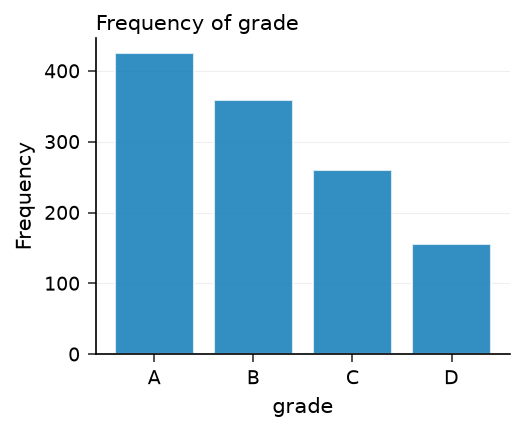

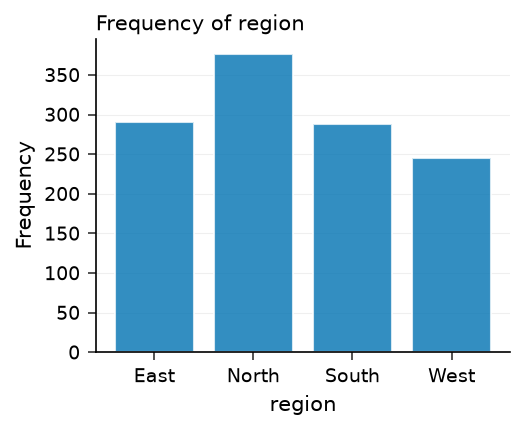

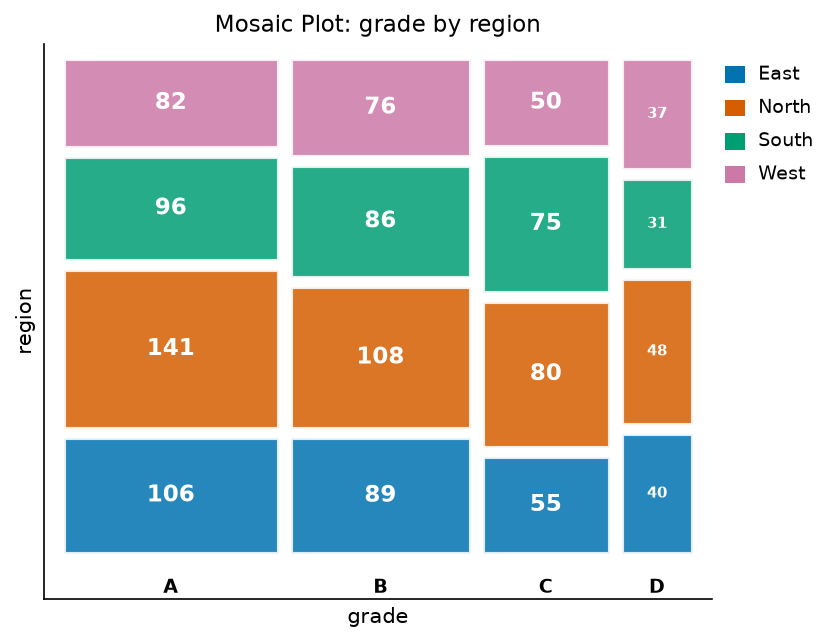

In [2]:
proc freq data=loans;
   tables grade region grade*region / nocum nopercent;
run;

proc means data=loans n mean std min max maxdec=3;
   var dti loan_amt lgd;
run;

## Step 3 — Construct the design matrix with PROC GLMMOD

This is the heart of the workflow. The `CLASS` statement declares `grade` and `region` as classification variables (it **must** precede the `MODEL` statement). The `MODEL` statement names the dependent (`lgd`) and the effects:

- `grade region` — categorical main effects (one GLM-coded column per level)
- `dti loan_amt` — continuous main effects (passed through unchanged)
- `grade*dti` — the grade-specific DTI slope interaction

We request two output datasets:

- `OUTDESIGN=design` — one row per loan, with the GLM-coded numeric columns. This is what `PROC REG` will consume.
- `OUTPARM=parm` — one row per design column, mapping each column number back to the effect and class level it represents.

`ORDER=DATA` keeps grade levels in A-B-C-D order, and `PREFIX=X` names the design columns `X1, X2, ...` to make the regression output readable. GLM coding is **non-full-rank**: the four grade levels expand to four dummy columns (not three), and likewise for region and the interaction, so the matrix here has 15 columns — `X1` is GLMMOD's own intercept column, `X2-X5` the grade dummies, `X6-X9` region, `X10-X11` the continuous covariates, and `X12-X15` the grade*dti interaction.

In [3]:
proc glmmod data=loans order=data prefix=X
            outdesign=design outparm=parm;
   class grade region;
   model lgd = grade region dti loan_amt grade*dti;
run;

The GLMMOD Procedure


Number of Observations Read: 1200
Number of Design Columns: 15     

         Parameter Information         

_COLNUM_  EFFNAME    grade     region  
--------  ---------  --------  --------
1         Intercept                    
2         grade      C                 
3         grade      B                 
4         grade      D                 
5         grade      A                 
6         region               East    
7         region               South   
8         region               North   
9         region               West    
10        dti                          
11        loan_amt                     
12        grade*dti  C                 
13        grade*dti  B                 
14        grade*dti  D                 
15        grade*dti  A                 




NOTE: PROC GLMMOD data=loans

NOTE: PROC GLMMOD statement used.


## Step 4 — Read the parameter map

The `OUTPARM=` dataset is the legend for the design matrix: `_COLNUM_` is the column number, `EFFNAME` is the generating effect, and the class variables show which level each column encodes (blank when the effect does not involve that class variable). Risk analysts use this to translate fitted coefficients back into business terms.

In [4]:
proc print data=parm noobs;
   title 'Design Matrix Column Map (OUTPARM)';
run;
title;

                                           Design Matrix Column Map (OUTPARM)                                           

_COLNUM_    EFFNAME  GRADE  REGION
       1  Intercept
       2  grade      C
       3  grade      B
       4  grade      D
       5  grade      A
       6  region            East
       7  region            South
       8  region            North
       9  region            West
      10  dti
      11  loan_amt
      12  grade*dti  C
      13  grade*dti  B
      14  grade*dti  D
      15  grade*dti  A



NOTE: PROC PRINT data=parm

NOTE: PROC PRINT completed: 15 observations printed, 4 variables


## Step 5 — Fit the LGD model with PROC REG on the design matrix

Because `PROC REG` cannot expand CLASS effects itself, we feed it the GLM-coded columns from `OUTDESIGN=`. The `OUTDESIGN=` set holds only the design columns, so we first re-attach the dependent `lgd` from the original `loans` file with a positional `MERGE` (GLMMOD emits one design row per input row, in input order, so this is a clean one-to-one join). We then regress `lgd` on `X2--X15` using the `--` positional name range, which selects every variable between the two named columns in dataset order. We skip `X1` because it is GLMMOD's own intercept dummy and `PROC REG` already adds an intercept. GLM coding is over-parameterized (one redundant dummy per CLASS effect), so although the model lists 14 design columns the SS partition carries only **11 model degrees of freedom** — `PROC REG` resolves the rank deficiency automatically.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                                Dependent Variable: lgd                                                 

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                  11        38.75684      3.52335   1393.46    <.0001
Error                1188         3.00385      0.00253                    
Corrected Total      1199        41.76069                                 

Root MSE           0.05028    R-Square            0.9281
Dependent Mean       0.37392    Adj R-Sq            0.9274
Coeff Var         13.44794

                       Parameter Estimates                       

Variable         DF  Estimate  Standard Error   t

NOTE: DATA design_lgd

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC REG data=design_lgd

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


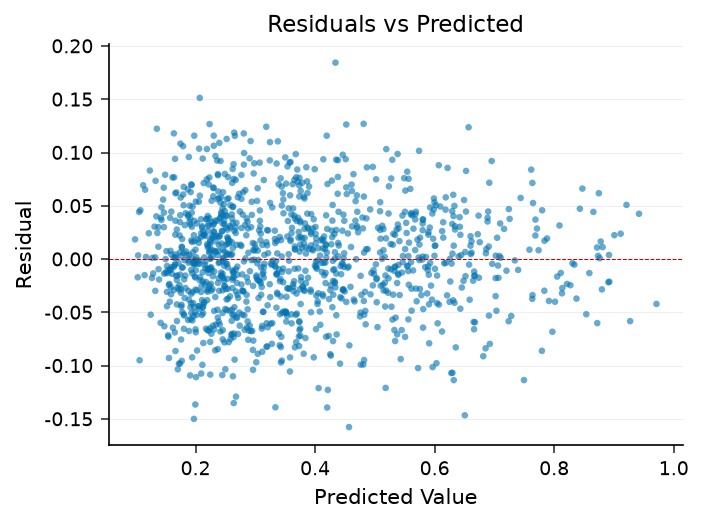

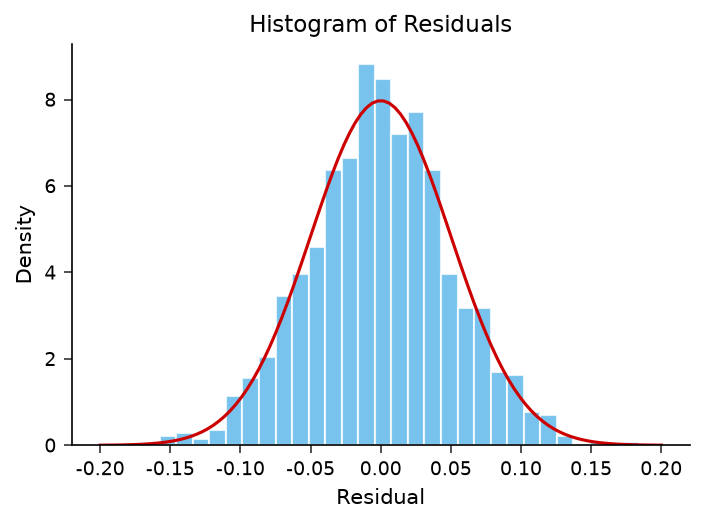

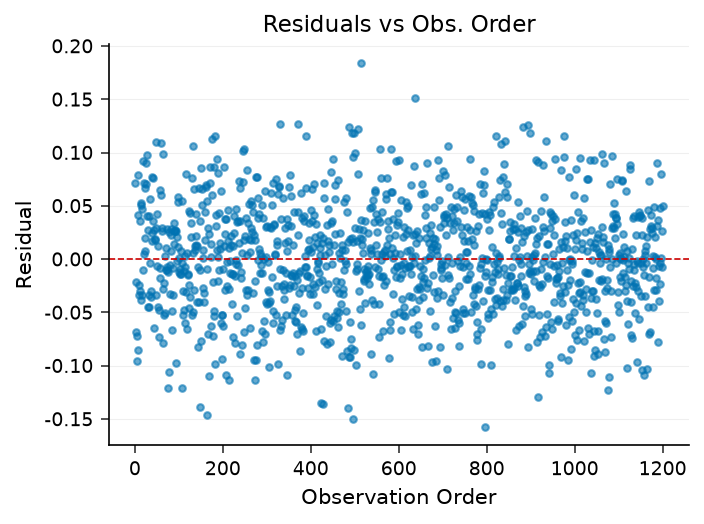

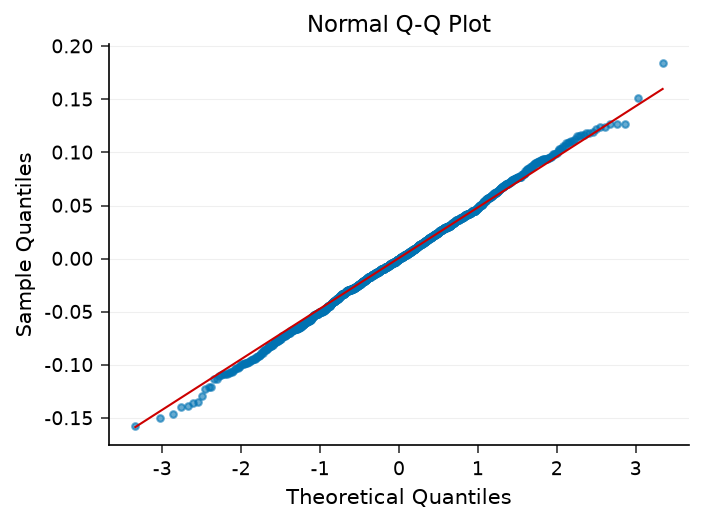

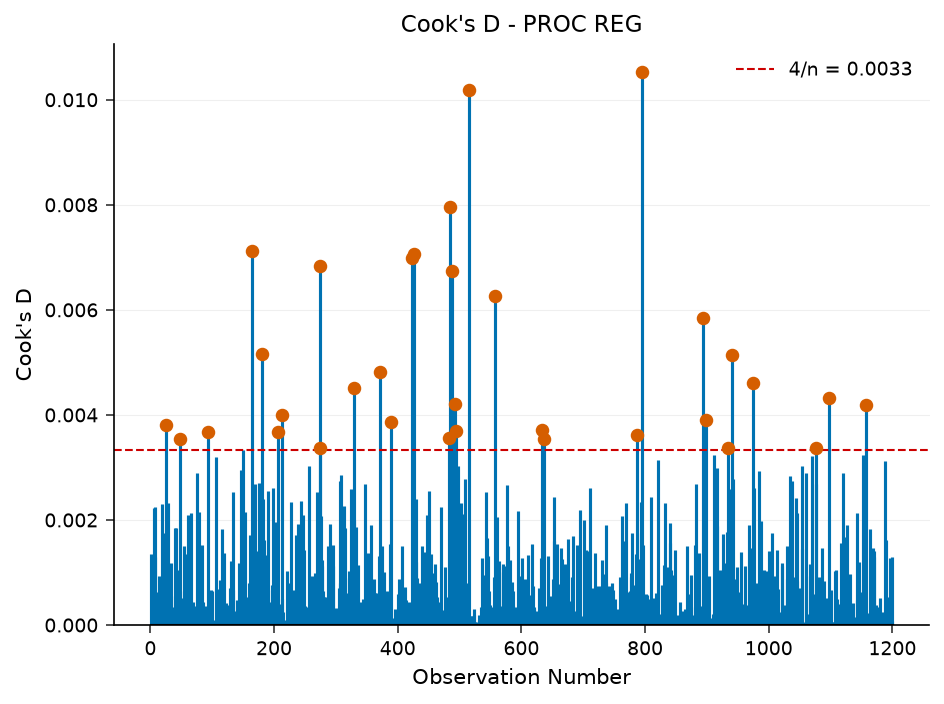

In [5]:
/* Re-attach the dependent (OUTDESIGN= carries only the design columns).
   GLMMOD writes one design row per input row in input order, so a
   positional MERGE rejoins lgd one-to-one. */
data design_lgd;
   merge loans(keep=lgd) design;
run;

proc reg data=design_lgd;
   model lgd = X2--X15;
run;
quit;

## Step 6 — A second use case: factorial screening of credit-policy levers

GLMMOD also shines for **two-level factorial screening**. Suppose a credit-policy committee runs a 16-point fractional design over five binary levers (a tighter pricing band, a higher score cutoff, a lower DTI cap, a lower LTV cap, a shorter maximum term) and records a portfolio `approval_rate` response. We want to screen all main effects and **two-factor interactions**.

The `MODEL` bar operator with an order limit — `pricing|score_cut|dti_cap|ltv_cap|term_max@2` — expands to every main effect and every pairwise interaction (but no three-way or higher terms). We capture the resulting design matrix via `ODS OUTPUT DesignPoints=`.

In [6]:
data screening;
   call streaminit(7);
   do pricing   = -1, 1;
   do score_cut = -1, 1;
   do dti_cap   = -1, 1;
   do ltv_cap   = -1, 1;
      term_max = pricing*score_cut*dti_cap*ltv_cap;  /* 2^(5-1) generator */
      approval_rate = 62
         + 5.0*pricing  - 3.5*score_cut
         - 2.0*dti_cap  + 1.5*ltv_cap
         + 2.5*pricing*score_cut
         + 1.0*rand('Normal');
      output;
   end; end; end; end;
run;

NOTE: DATA screening


NOTE: Wrote screening (16 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [7]:
ods output DesignPoints = screen_design;
proc glmmod data=screening;
   model approval_rate =
      pricing|score_cut|dti_cap|ltv_cap|term_max@2;
run;

The GLMMOD Procedure


Number of Observations Read: 16
Number of Design Columns: 16   

   Parameter Information    

_COLNUM_  EFFNAME           
--------  ------------------
1         Intercept         
2         pricing           
3         score_cut         
4         dti_cap           
5         ltv_cap           
6         term_max          
7         pricing*score_cut 
8         pricing*dti_cap   
9         pricing*ltv_cap   
10        pricing*term_max  
11        score_cut*dti_cap 
12        score_cut*ltv_cap 
13        score_cut*term_max
14        dti_cap*ltv_cap   
15        dti_cap*term_max  
16        ltv_cap*term_max  




NOTE: ODS OUTPUT: DESIGNPOINTS -> screen_design
NOTE: PROC GLMMOD data=screening

NOTE: PROC GLMMOD statement used.


## Step 7 — Forward-selection screening regression

With the screening design matrix in hand, `PROC REG` performs forward selection to flag which policy levers and interactions actually move the approval rate. As in Step 5, the `ODS OUTPUT` design set holds only the design columns, so we positionally `MERGE` the `approval_rate` response back from `screening` before regressing. The `--` range then pulls in every design column the bar expansion produced (`Col2--Col16`, skipping the intercept dummy `Col1`); `SELECTION=FORWARD` enters terms while they clear the `SLENTRY=` significance threshold.

In [8]:
/* Re-attach the response, then forward-select over the screening design. */
data screen_fit;
   merge screening(keep=approval_rate) screen_design;
run;

proc reg data=screen_fit;
   model approval_rate = Col2--Col16
      / selection = forward
        slentry   = 0.10
        details   = summary;
run;
quit;

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                           Dependent Variable: approval_rate                                            

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   7       754.32503    107.76072   1049.87    <.0001
Error                   8         0.82113      0.10264                    
Corrected Total        15       755.14616                                 

Root MSE           0.32038    R-Square            0.9989
Dependent Mean      62.00253    Adj R-Sq            0.9980
Coeff Var          0.51672

                       Parameter Estimates                       

Variable         DF  Estimate  Standard Error   t

NOTE: DATA screen_fit

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC REG data=screen_fit

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: PROC REG ODS Graphics generated.


## Interpreting the results

- **Design-matrix construction.** `PROC GLMMOD` turned a mix of two CLASS variables, two continuous covariates, and a class-by-continuous interaction into a single 15-column numeric design matrix (`OUTDESIGN=design`) plus a human-readable column map (`OUTPARM=parm`). This is the canonical way to give a CLASS-free procedure like `PROC REG` access to categorical and interaction effects. Because `OUTDESIGN=` carries only the design columns, we re-attached the modeled response with a one-to-one positional `MERGE` before regressing.

- **LGD model.** On the 1,200-loan portfolio the regression on `X2--X15` fits well — R-square **0.9281**, overall F **1393.46** on 11 model degrees of freedom (p < .0001). The fitted coefficients recover the planted structure: the DTI main slope `X10` is large and highly significant (estimate **0.384**, t = 47.26), `loan_amt` (`X11`) is positive and significant (estimate **0.00162**, t = 14.15), and the grade*dti interaction column for the worst grade (`X14` = grade D) carries the steepest extra slope (estimate **0.406**, t = 18.23) versus **0.165** for grade C (`X12`) — the DTI risk slope steepening for weaker grades, exactly as simulated. One GLM-coded dummy inside each CLASS effect is redundant by construction, so the 14 design columns collapse to 11 estimable model degrees of freedom — the over-parameterization that GLM coding produces and `PROC REG` resolves automatically.

- **Policy screening.** The `@2` bar expansion gave the committee a main-effects-plus-two-way design without manually typing 15 interaction terms. Forward selection (`SLENTRY=0.10`) entered seven terms in order: `pricing` (`Col2`, largest positive lever, **+4.81**), `score_cut` (`Col3`, **-3.60**), the `pricing*score_cut` synergy (`Col7`, **+2.15**), `dti_cap` (`Col4`, **-1.95**), `ltv_cap` (`Col5`, **+1.49**), then `pricing*ltv_cap` (`Col9`, **+0.50**) and `term_max` (`Col6`, **-0.35**). The first five are exactly the active terms in the simulated response; the last two are small, statistically significant artifacts of the simulation noise that the liberal 0.10 entry threshold admitted — a useful reminder that screening selection at a loose `SLENTRY=` can pick up minor terms. The model explains essentially all the variance (R-square **0.9989**), a compact, defensible story for a credit-policy memo.

**Takeaway:** `PROC GLMMOD` is rarely the final analysis, but it is the bridge that lets simple, transparent regression procedures model the categorical and interaction structure that real banking data always contains.